# CPU Latency Test for Saved Models

This notebook benchmarks saved models under the project-level `models/` directory on a CPU machine.

It is designed to:
- prefer `*_scripted.pt` TorchScript files when available,
- fall back to checkpoint `.pt` files if needed,
- support MLP, CNN, LSTM, Standard Transformer, and Set Transformer families,
- measure CPU inference latency with fixed thread count,
- export results to CSV.

**Expected project layout**
- `notebooks/`
- `src/`
- `models/`

Run this notebook from `notebooks/` or project root.


In [11]:
from __future__ import annotations

import importlib
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

plt.rcParams.update({
    'figure.figsize': (8, 4.8),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'src').exists() and (p / 'models').exists():
            return p
    raise FileNotFoundError('Could not find project root containing both src/ and models/.')

PROJECT_ROOT = find_project_root()
MODELS_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'logs' / 'latency'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in os.sys.path:
    os.sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('MODELS_DIR   =', MODELS_DIR)
print('OUTPUT_DIR   =', OUTPUT_DIR)

device = torch.device('cpu')
torch.set_num_threads(1)
print('device =', device)
print('num threads =', torch.get_num_threads())


PROJECT_ROOT = /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project
MODELS_DIR   = /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/models
OUTPUT_DIR   = /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/notebooks/logs/latency
device = cpu
num threads = 1


In [12]:
USE_SCRIPTED_FIRST = True
BATCH_SIZES = [1]
N_WARMUP = 50
N_RUNS = 300
DTYPE = torch.float32

all_pt = sorted(MODELS_DIR.glob('*.pt'))
scripted_files = sorted([p for p in all_pt if p.name.endswith('_scripted.pt')])
checkpoint_files = sorted([p for p in all_pt if not p.name.endswith('_scripted.pt')])

print('Found scripted files:')
for p in scripted_files:
    print(' -', p.name)

print('\nFound checkpoint files:')
for p in checkpoint_files:
    print(' -', p.name)

if not all_pt:
    raise FileNotFoundError(f'No .pt files found under {MODELS_DIR}')


Found scripted files:

Found checkpoint files:
 - cnn_coordinate.pt
 - cnn_joint.pt
 - cnn_multitask.pt
 - lstm_coordinate.pt
 - lstm_joint.pt
 - lstm_multitask.pt
 - mlp_coordinate.pt
 - mlp_joint.pt
 - mlp_multitask.pt
 - set_transformer_coordinate.pt
 - set_transformer_joint.pt
 - set_transformer_multitask.pt
 - transformer_coordinate.pt
 - transformer_joint.pt
 - transformer_multitask.pt


In [13]:
def import_from_candidates(module_candidates: list[str], class_name: str):
    last_err = None
    for mod_name in module_candidates:
        try:
            mod = importlib.import_module(mod_name)
            return getattr(mod, class_name)
        except Exception as e:
            last_err = e
    raise ImportError(f'Could not import {class_name} from {module_candidates}. Last error: {last_err}')

CLASS_MODULE_CANDIDATES = {
    'JointMLPModel': ['src.models.mlp_joint'],
    'MultiTaskMLPModel': ['src.models.mlp_multitask'],
    'CoordinateMLPModel': ['src.models.mlp_coordinates'],

    'CNNJointModel': ['src.models.cnn_joint'],
    'CNNMultiTaskModel': ['src.models.cnn_multitask'],
    'CNNCoordinateModel': ['src.models.cnn_coordinates'],

    'LSTMJointModel': ['src.models.lstm_joint_v2', 'src.models.lstm_joint'],
    'LSTMMultiTaskModel': ['src.models.lstm_multitask_v2', 'src.models.lstm_multitask'],
    'LSTMCoordinateModel': ['src.models.lstm_coordinates_v2', 'src.models.lstm_coordinates'],

    'JointTransformerModel': ['src.models.standard_transformer'],
    'MultiTaskTransformerModel': ['src.models.standard_transformer'],
    'CoordinateTransformerModel': ['src.models.standard_transformer'],

    'JointSetTransformerModel': ['src.models.set_transformer'],
    'MultiTaskSetTransformerModel': ['src.models.set_transformer'],
    'CoordinateSetTransformerModel': ['src.models.set_transformer'],
}

def maybe_build_backbone_cfg(model_class_name: str, model_kwargs: dict):
    kwargs = dict(model_kwargs or {})
    if 'backbone_cfg' not in kwargs:
        return kwargs
    if not isinstance(kwargs['backbone_cfg'], dict):
        return kwargs

    if 'SetTransformer' in model_class_name:
        cfg_cls = import_from_candidates(['src.models.set_transformer'], 'SetTransformerConfig')
        kwargs['backbone_cfg'] = cfg_cls(**kwargs['backbone_cfg'])
    elif 'Transformer' in model_class_name:
        cfg_cls = import_from_candidates(['src.models.standard_transformer'], 'TransformerConfig')
        kwargs['backbone_cfg'] = cfg_cls(**kwargs['backbone_cfg'])
    return kwargs

def load_checkpoint_file(path: Path):
    # PyTorch 2.6 changed torch.load default weights_only=True.
    # Our checkpoints include trusted metadata (lists / numpy-derived objects),
    # so we must load with weights_only=False.
    return torch.load(path, map_location='cpu', weights_only=False)

def build_model_from_checkpoint_payload(ckpt: dict):
    model_class_name = ckpt['model_class_name']
    in_dim = ckpt['in_dim']
    model_kwargs = maybe_build_backbone_cfg(model_class_name, ckpt.get('model_kwargs', {}))

    cls = import_from_candidates(CLASS_MODULE_CANDIDATES[model_class_name], model_class_name)
    model = cls(in_dim=in_dim, **model_kwargs)
    model.load_state_dict(ckpt['state_dict'])
    model.to(device)
    model.eval()
    return model

def count_trainable_params(model) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def load_model_artifact(path: Path):
    name = path.name
    if name.endswith('_scripted.pt'):
        model = torch.jit.load(str(path), map_location=device)
        model.eval()
        artifact_type = 'scripted'
        base_name = name.replace('_scripted.pt', '')
        paired_ckpt = MODELS_DIR / f'{base_name}.pt'
        metadata = {}
        params = None
        in_dim = None
        if paired_ckpt.exists():
            ckpt = load_checkpoint_file(paired_ckpt)
            metadata = ckpt
            in_dim = ckpt.get('in_dim')
            try:
                tmp_model = build_model_from_checkpoint_payload(ckpt)
                params = count_trainable_params(tmp_model)
            except Exception:
                params = None
        return model, artifact_type, metadata, params, in_dim

    ckpt = load_checkpoint_file(path)
    model = build_model_from_checkpoint_payload(ckpt)
    artifact_type = 'checkpoint'
    params = count_trainable_params(model)
    in_dim = ckpt.get('in_dim')
    return model, artifact_type, ckpt, params, in_dim


In [14]:
def choose_artifacts() -> list[Path]:
    if USE_SCRIPTED_FIRST and scripted_files:
        chosen = list(scripted_files)
        scripted_bases = {p.name.replace('_scripted.pt', '') for p in scripted_files}
        for p in checkpoint_files:
            base = p.name.replace('.pt', '')
            if base not in scripted_bases:
                chosen.append(p)
        return sorted(chosen)
    return sorted(checkpoint_files if checkpoint_files else scripted_files)

ARTIFACTS = choose_artifacts()
print('Artifacts selected for benchmarking:')
for p in ARTIFACTS:
    print(' -', p.name)

loaded = []
for p in ARTIFACTS:
    model, artifact_type, metadata, params, in_dim = load_model_artifact(p)
    loaded.append({
        'path': p,
        'name': p.name,
        'artifact_type': artifact_type,
        'model': model,
        'metadata': metadata,
        'params': params,
        'in_dim': in_dim,
    })

inventory_rows = []
for item in loaded:
    md = item['metadata'] or {}
    inventory_rows.append({
        'file': item['name'],
        'artifact_type': item['artifact_type'],
        'model_class_name': md.get('model_class_name'),
        'task': md.get('task'),
        'in_dim': item['in_dim'],
        'params': item['params'],
    })

inventory_df = pd.DataFrame(inventory_rows).sort_values(['model_class_name', 'task', 'file'])
display(inventory_df)


Artifacts selected for benchmarking:
 - cnn_coordinate.pt
 - cnn_joint.pt
 - cnn_multitask.pt
 - lstm_coordinate.pt
 - lstm_joint.pt
 - lstm_multitask.pt
 - mlp_coordinate.pt
 - mlp_joint.pt
 - mlp_multitask.pt
 - set_transformer_coordinate.pt
 - set_transformer_joint.pt
 - set_transformer_multitask.pt
 - transformer_coordinate.pt
 - transformer_joint.pt
 - transformer_multitask.pt


,file,artifact_type,model_class_name,task,in_dim,params
0,cnn_coordinate.pt,checkpoint,CNNCoordinateModel,coordinate,1040,1582082
1,cnn_joint.pt,checkpoint,CNNJointModel,joint,1040,1584909
2,cnn_multitask.pt,checkpoint,CNNMultiTaskModel,multitask,1040,1583624
6,mlp_coordinate.pt,checkpoint,CoordinateMLPModel,coordinate,1040,1726210
9,set_transformer_coordinate.pt,checkpoint,CoordinateSetTransformerModel,coordinate,1040,481794
12,transformer_coordinate.pt,checkpoint,CoordinateTransformerModel,coordinate,1040,349442
7,mlp_joint.pt,checkpoint,JointMLPModel,joint,1040,1729037
10,set_transformer_joint.pt,checkpoint,JointSetTransformerModel,joint,1040,483213
13,transformer_joint.pt,checkpoint,JointTransformerModel,joint,1040,350861
3,lstm_coordinate.pt,checkpoint,LSTMCoordinateModel,coordinate,1040,1639203


In [15]:
def make_synthetic_input(batch_size: int, in_dim: int, dtype=DTYPE):
    return torch.randn(batch_size, in_dim, dtype=dtype, device=device)

def measure_latency(model, x_sample, n_warmup=N_WARMUP, n_runs=N_RUNS):
    model.eval()
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(x_sample)

        times_ms = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _ = model(x_sample)
            t1 = time.perf_counter()
            times_ms.append((t1 - t0) * 1000.0)

    arr = np.asarray(times_ms, dtype=np.float64)
    return {
        'mean_ms': float(arr.mean()),
        'median_ms': float(np.median(arr)),
        'p95_ms': float(np.percentile(arr, 95)),
        'min_ms': float(arr.min()),
        'max_ms': float(arr.max()),
    }

benchmark_rows = []

for item in loaded:
    md = item['metadata'] or {}
    in_dim = item['in_dim']
    if in_dim is None:
        print(f"Skipping {item['name']} because in_dim could not be determined.")
        continue

    for batch_size in BATCH_SIZES:
        x_sample = make_synthetic_input(batch_size=batch_size, in_dim=in_dim)
        lat = measure_latency(item['model'], x_sample)
        benchmark_rows.append({
            'file': item['name'],
            'artifact_type': item['artifact_type'],
            'model_class_name': md.get('model_class_name'),
            'task': md.get('task'),
            'params': item['params'],
            'in_dim': in_dim,
            'batch_size': batch_size,
            **lat,
        })
        print(f"Benchmarked {item['name']} @ batch={batch_size}: p95={lat['p95_ms']:.4f} ms")

latency_df = pd.DataFrame(benchmark_rows).sort_values(['batch_size', 'p95_ms']).reset_index(drop=True)
display(latency_df)


Benchmarked cnn_coordinate.pt @ batch=1: p95=10.4215 ms
Benchmarked cnn_joint.pt @ batch=1: p95=10.5393 ms
Benchmarked cnn_multitask.pt @ batch=1: p95=10.5274 ms
Benchmarked lstm_coordinate.pt @ batch=1: p95=108.2930 ms
Benchmarked lstm_joint.pt @ batch=1: p95=108.6571 ms
Benchmarked lstm_multitask.pt @ batch=1: p95=110.6628 ms
Benchmarked mlp_coordinate.pt @ batch=1: p95=0.5263 ms
Benchmarked mlp_joint.pt @ batch=1: p95=0.5291 ms
Benchmarked mlp_multitask.pt @ batch=1: p95=0.5613 ms
Benchmarked set_transformer_coordinate.pt @ batch=1: p95=13.9879 ms
Benchmarked set_transformer_joint.pt @ batch=1: p95=13.3436 ms
Benchmarked set_transformer_multitask.pt @ batch=1: p95=13.6786 ms
Benchmarked transformer_coordinate.pt @ batch=1: p95=8.0912 ms
Benchmarked transformer_joint.pt @ batch=1: p95=11.0345 ms
Benchmarked transformer_multitask.pt @ batch=1: p95=11.2395 ms


,file,artifact_type,model_class_name,task,params,in_dim,batch_size,mean_ms,median_ms,p95_ms,min_ms,max_ms
0,mlp_coordinate.pt,checkpoint,CoordinateMLPModel,coordinate,1726210,1040,1,0.521255,0.522431,0.526333,0.513738,0.556637
1,mlp_joint.pt,checkpoint,JointMLPModel,joint,1729037,1040,1,0.523069,0.524837,0.529067,0.515373,0.549729
2,mlp_multitask.pt,checkpoint,MultiTaskMLPModel,multitask,1727752,1040,1,0.555620,0.557377,0.561310,0.547994,0.580810
3,transformer_coordinate.pt,checkpoint,CoordinateTransformerModel,coordinate,349442,1040,1,8.011977,8.000313,8.091225,7.965701,8.407505
4,cnn_coordinate.pt,checkpoint,CNNCoordinateModel,coordinate,1582082,1040,1,10.313357,10.300081,10.421541,10.207112,10.826502
5,cnn_multitask.pt,checkpoint,CNNMultiTaskModel,multitask,1583624,1040,1,10.420834,10.400028,10.527357,10.303902,10.784891
6,cnn_joint.pt,checkpoint,CNNJointModel,joint,1584909,1040,1,10.391769,10.367810,10.539313,10.292011,10.984623
7,transformer_joint.pt,checkpoint,JointTransformerModel,joint,350861,1040,1,10.809764,10.775627,11.034540,10.727800,11.380446
8,transformer_multitask.pt,checkpoint,MultiTaskTransformerModel,multitask,366728,1040,1,10.935558,10.882590,11.239504,10.837089,11.781594
9,set_transformer_joint.pt,checkpoint,JointSetTransformerModel,joint,483213,1040,1,13.006873,12.977064,13.343566,12.535618,14.101015


In [16]:
csv_path = OUTPUT_DIR / 'latency_results.csv'
latency_df.to_csv(csv_path, index=False)
print('Saved:', csv_path)

pivot = latency_df.pivot_table(
    index=['model_class_name', 'task'],
    columns='batch_size',
    values='p95_ms',
    aggfunc='first',
)
display(pivot)


Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/notebooks/logs/latency/latency_results.csv


,batch_size,1
model_class_name,task,
CNNCoordinateModel,coordinate,10.421541
CNNJointModel,joint,10.539313
CNNMultiTaskModel,multitask,10.527357
CoordinateMLPModel,coordinate,0.526333
CoordinateSetTransformerModel,coordinate,13.987939
CoordinateTransformerModel,coordinate,8.091225
JointMLPModel,joint,0.529067
JointSetTransformerModel,joint,13.343566
JointTransformerModel,joint,11.034540


Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/notebooks/logs/latency/latency_p95_batch1.png


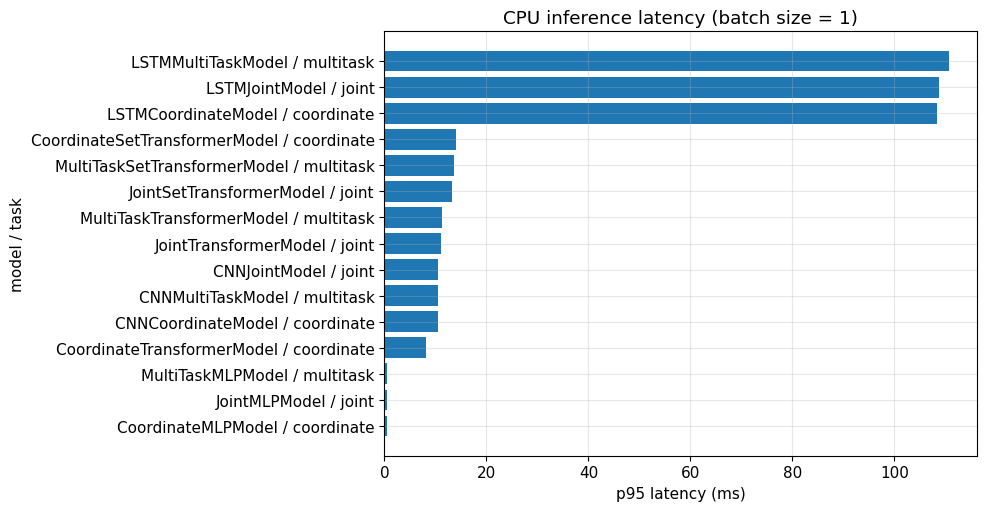

In [17]:
plot_df = latency_df[latency_df['batch_size'] == 1].copy()
plot_df['label'] = plot_df['model_class_name'].fillna(plot_df['file']) + ' / ' + plot_df['task'].fillna('?')
plot_df = plot_df.sort_values('p95_ms')

plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
plt.barh(plot_df['label'], plot_df['p95_ms'])
plt.xlabel('p95 latency (ms)')
plt.ylabel('model / task')
plt.title('CPU inference latency (batch size = 1)')
plt.tight_layout()

fig_path = OUTPUT_DIR / 'latency_p95_batch1.png'
plt.savefig(fig_path, dpi=300)
print('Saved:', fig_path)
plt.show()


## Machine Specification

In [18]:
# Machine / environment spec for latency reporting
from __future__ import annotations

import os
import platform
import socket
import subprocess
from pathlib import Path

import torch

def run_cmd(cmd: str) -> str:
    try:
        out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True)
        return out.strip()
    except Exception as e:
        return f"[unavailable: {e}]"

print("=" * 80)
print("MACHINE SPEC")
print("=" * 80)

print(f"Hostname           : {socket.gethostname()}")
print(f"Platform           : {platform.platform()}")
print(f"System             : {platform.system()} {platform.release()}")
print(f"Machine            : {platform.machine()}")
print(f"Processor          : {platform.processor()}")
print(f"Python version     : {platform.python_version()}")
print(f"PyTorch version    : {torch.__version__}")
print(f"CUDA available     : {torch.cuda.is_available()}")
print(f"CPU threads (torch): {torch.get_num_threads()}")
print(f"CPU count (os)     : {os.cpu_count()}")

print("\n" + "=" * 80)
print("CPU INFO")
print("=" * 80)
print(run_cmd("lscpu"))

print("\n" + "=" * 80)
print("MEMORY INFO")
print("=" * 80)
print(run_cmd("free -h"))

print("\n" + "=" * 80)
print("TOP /PROC CPU MODEL")
print("=" * 80)
print(run_cmd("grep -m 1 'model name' /proc/cpuinfo"))
print(run_cmd("grep -m 1 'cpu cores' /proc/cpuinfo"))
print(run_cmd("grep -m 1 'siblings' /proc/cpuinfo"))

print("\n" + "=" * 80)
print("NUMA / THREADING")
print("=" * 80)
print(f"OMP_NUM_THREADS    : {os.environ.get('OMP_NUM_THREADS')}")
print(f"MKL_NUM_THREADS    : {os.environ.get('MKL_NUM_THREADS')}")
print(f"OPENBLAS_NUM_THREADS: {os.environ.get('OPENBLAS_NUM_THREADS')}")

# Save a text copy next to latency outputs if OUTPUT_DIR exists
if "OUTPUT_DIR" in globals():
    spec_path = Path(OUTPUT_DIR) / "machine_spec.txt"
    with open(spec_path, "w", encoding="utf-8") as f:
        f.write("=" * 80 + "\n")
        f.write("MACHINE SPEC\n")
        f.write("=" * 80 + "\n")
        f.write(f"Hostname           : {socket.gethostname()}\n")
        f.write(f"Platform           : {platform.platform()}\n")
        f.write(f"System             : {platform.system()} {platform.release()}\n")
        f.write(f"Machine            : {platform.machine()}\n")
        f.write(f"Processor          : {platform.processor()}\n")
        f.write(f"Python version     : {platform.python_version()}\n")
        f.write(f"PyTorch version    : {torch.__version__}\n")
        f.write(f"CUDA available     : {torch.cuda.is_available()}\n")
        f.write(f"CPU threads (torch): {torch.get_num_threads()}\n")
        f.write(f"CPU count (os)     : {os.cpu_count()}\n\n")

        f.write("=" * 80 + "\nCPU INFO\n" + "=" * 80 + "\n")
        f.write(run_cmd("lscpu") + "\n\n")

        f.write("=" * 80 + "\nMEMORY INFO\n" + "=" * 80 + "\n")
        f.write(run_cmd("free -h") + "\n\n")

        f.write("=" * 80 + "\nTOP /PROC CPU MODEL\n" + "=" * 80 + "\n")
        f.write(run_cmd("grep -m 1 'model name' /proc/cpuinfo") + "\n")
        f.write(run_cmd("grep -m 1 'cpu cores' /proc/cpuinfo") + "\n")
        f.write(run_cmd("grep -m 1 'siblings' /proc/cpuinfo") + "\n\n")

        f.write("=" * 80 + "\nNUMA / THREADING\n" + "=" * 80 + "\n")
        f.write(f"OMP_NUM_THREADS     : {os.environ.get('OMP_NUM_THREADS')}\n")
        f.write(f"MKL_NUM_THREADS     : {os.environ.get('MKL_NUM_THREADS')}\n")
        f.write(f"OPENBLAS_NUM_THREADS: {os.environ.get('OPENBLAS_NUM_THREADS')}\n")

    print(f"\nSaved machine spec to: {spec_path}")

MACHINE SPEC
Hostname           : atl1-1-02-010-2-2.pace.gatech.edu
Platform           : Linux-5.14.0-570.62.1.el9_6.x86_64-x86_64-with-glibc2.34
System             : Linux 5.14.0-570.62.1.el9_6.x86_64
Machine            : x86_64
Processor          : x86_64
Python version     : 3.10.10
PyTorch version    : 2.11.0+cu130
CUDA available     : False
CPU threads (torch): 1
CPU count (os)     : 24

CPU INFO
Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           46 bits physical, 48 bits virtual
Byte Order:                              Little Endian
CPU(s):                                  24
On-line CPU(s) list:                     0-23
Vendor ID:                               GenuineIntel
Model name:                              Intel(R) Xeon(R) Gold 6226 CPU @ 2.70GHz
CPU family:                              6
Model:                                   85
Thread(s) per core:                      1
Core(

## Notes

- For the fairest CPU comparison, keep `torch.set_num_threads(1)` fixed.
- Use the same batch size, warmup count, and number of timed runs across models.
- TorchScript files are preferred for portable CPU benchmarking.
- If a scripted model exists, this notebook uses it first and reads the paired checkpoint metadata when available.
